## Laboratorium 3

### Opis
Celem laboratorium jest klasyfikacja liści za pomocą metody *k* najbliższych sąsiadów - *k*NN (*k Nearest Neighbors*) z wykorzystaniem normalizacji.


### Zbiór danych

Zbiór danych znajduje się w katalogu `dataset/*`. Jest to zmodyfikowany zbiór danych znajdujący się pod adresem: <https://archive.ics.uci.edu/ml/datasets/leaf>.

### Przesyłanie zadań

Wszystkie pliki należy spakować archiwizatorem **zip** i przesłać za pośrednictwem platformy WIKAMP. Poniżej oczekiwana zawartość archiwum:

```
+-- 📂 [IMIE.NAZWISKO].zip
    +-- 📜 Lab03.ipynb
    +-- 📂 dataset
        +-- 📜 dataset.npz
        +-- 📜 ReadMe.pdf
```



### Zadanie 1

* Wybierz 10 dowolnych gatunków liści (będziesz je używać w kolejnych zadaniach) oraz wszystkie cechy.
* Przeprowadź klasyfikację za pomocą klasyfikatora [*k*NN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).
* Znajdź optymalne *k*.
* Wyświetl najwyższy wynik klasyfikacji (*accuracy*).


In [5]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

In [2]:
with open('./dataset/dataset.npz', 'rb') as f:
    data = np.load(f)
    train, test = data['train'], data['test']

In [72]:
train_df = pd.DataFrame(train)
test_df = pd.DataFrame(test)

In [73]:
all_classes = train_df[0].unique()
all_classes.sort()
all_classes

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32.,
       33., 34., 35., 36.])

In [74]:
classes = [3,5,7,9,11,13,15,22,25,30]
train_df = train_df[train_df[0].isin(classes)]
test_df = test_df[test_df[0].isin(classes)]
sorted(train_df[0].unique())

[3.0, 5.0, 7.0, 9.0, 11.0, 13.0, 15.0, 22.0, 25.0, 30.0]

In [75]:
y = train_df[0].values
X = train_df.drop(columns=[0,1]).values
X_test = test_df.drop(columns=[0,1]).values

In [86]:
from matplotlib import pyplot as plt

In [89]:
neigh = KNeighborsClassifier(n_neighbors=1)
neigh.fit(X, y)
test_pred = neigh.predict(X_test)
labels = test_df[0].values

res = [i==j for i,j in zip(test_pred,labels)]

acc = sum(res)/len(res)

print(f'Accuracy: {acc:.4f}')

Accuracy: 0.7769


In [100]:
test_pred[:10]

array([30., 13.,  9.,  3., 13., 11., 30., 13.,  9., 11.])

In [101]:
labels[:10]

array([30., 13.,  9.,  3., 13., 11., 30., 13., 30., 11.])

[0.7768595041322314, 0.7582644628099173, 0.7913223140495868, 0.7892561983471075, 0.7933884297520661, 0.7830578512396694, 0.7975206611570248, 0.7975206611570248, 0.7913223140495868, 0.7913223140495868]


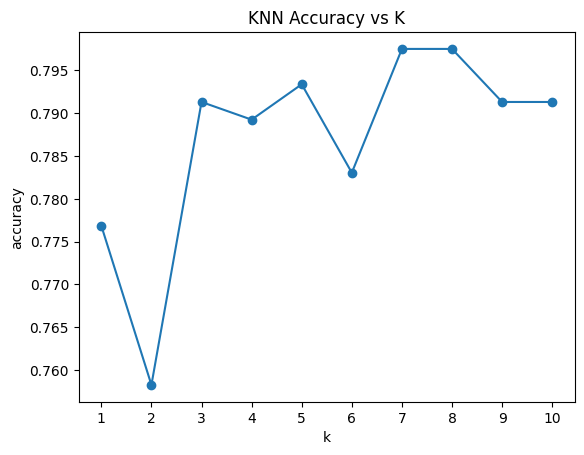

In [ ]:

accuracy = []
for k in range(1,11):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X, y)
    test_pred = neigh.predict(X_test)
    labels = test_df[0].values

    res = [i==j for i,j in zip(test_pred,labels)]

    acc = sum(res)/len(res)

    accuracy.append(acc)

    # print(f'Accuracy: {acc:.4f}')

plt.plot(range(1,11), accuracy, marker='o')
plt.xticks(range(1,11))
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('KNN Accuracy vs K')
plt.show()

### Zadanie 2
* Znormalizuj dane w zakresie 0-1. Możesz do tego celu wykorzystać gotową funkcję z biblioteki scikit-learn https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html.
>    **Ważne: współczynniki powinny być obliczone na zbiorze treningowym i te same powinny zostać zastosowane do normalizacji zbioru testowego.**
* Ponownie wykonaj klasyfikację z tymi samymi parametrami (co w zadaniu 1), ale na danych znormalizowanych.
* Znajdź optymalne *k*.
* Wyświetl wynik w postaci wykresu, gdzie na osi X znajduje się *k*, a na osi Y *accuracy*.
* Wyświetl najwyższy wynik klasyfikacji (*accuracy*).


In [106]:
from sklearn.preprocessing import MinMaxScaler

In [107]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X) # only on training dataset
X_test_norm = scaler.transform(X_test) # normalization test data

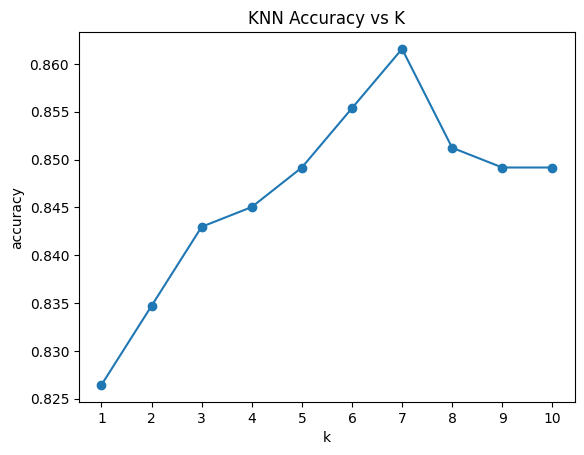

In [108]:
accuracy = []
for k in range(1,11):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_norm, y)
    test_pred = neigh.predict(X_test_norm)
    labels = test_df[0].values

    res = [i==j for i,j in zip(test_pred,labels)]

    acc = sum(res)/len(res)

    accuracy.append(acc)

    # print(f'Accuracy: {acc:.4f}')

plt.plot(range(1,11), accuracy, marker='o')
plt.xticks(range(1,11))
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('KNN Accuracy vs K')
plt.show()

### Zadanie 3

Results

* The effectiveness of the classifier significantly increased for normalized data
* Using the scikit-learn library greatly simplifies the work